In [1]:
import numpy as np
import pandas as pd

In [2]:
from sklearn.metrics import f1_score

In [3]:
import site
site.addsitedir("../dataprocessing")
from fakenews_functions import change_label

### Testing benchmark on FakeNewsCorpus test set

In [4]:
data = pd.read_csv("../data/data_stemmed.csv", index_col=0)
metadata = pd.read_csv("../data/995,000_rows.csv", usecols=["type"])

In [5]:
data["type"] = metadata["type"].apply(change_label)

In [6]:
data.dropna(inplace=True)

In [7]:
# Shuffle dataset randomly
data = data.sample(frac=1, random_state=0)
data.reset_index(inplace=True, drop=True)

In [8]:
split_index1 = int(len(data)*0.8)
split_index2 = int(len(data)*0.9)

# train_set = data.iloc[:split_index1]
# val_set = data.iloc[split_index1:split_index2]
test_set = data.iloc[split_index2:]

In [9]:
true_labels = test_set["type"].to_numpy(dtype=np.int64)

In [10]:
np.random.seed(0)
predictions = np.random.choice([0, 1], size=true_labels.shape)

In [11]:
f1_score(true_labels, predictions, pos_label=1)

0.49216104070875855

### Testing benchmark on LIAR dataset

In [13]:
data_liar = pd.read_csv("../data/liar_stemmed_data.csv", usecols=["content", "type"])

In [14]:
true_labels_liar = data_liar["type"].to_numpy(dtype=np.int64)

In [15]:
np.random.seed(0)
predictions_liar = np.random.choice([0, 1], size=true_labels_liar.shape)

In [16]:
f1_score(true_labels_liar, predictions_liar, pos_label=1)

0.4136657433056325

### Confusion matrix

In [17]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
plt.rcParams.update({'font.size': 16})

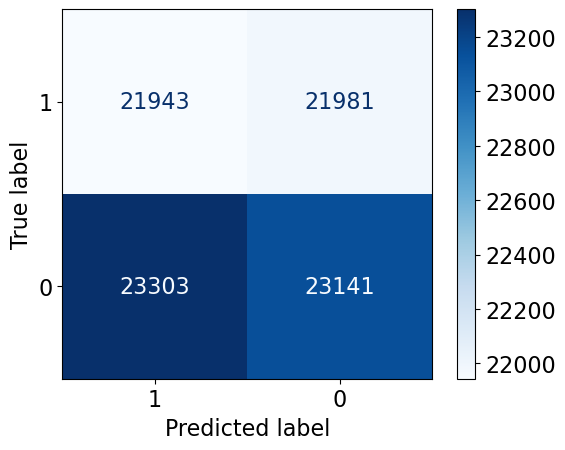

In [18]:
# For FakeNewsCorpus
fig, ax = plt.subplots()
ConfusionMatrixDisplay.from_predictions(
    true_labels, 
    predictions, 
    labels=[1, 0],
    display_labels=[1, 0],
    cmap="Blues",
    ax=ax
)

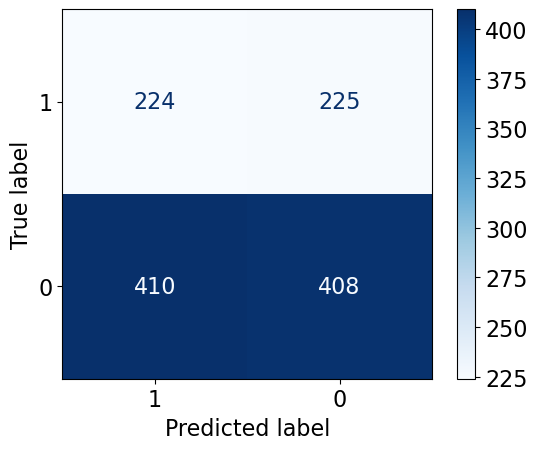

In [19]:
# For LIAR dataset
fig, ax = plt.subplots()
ConfusionMatrixDisplay.from_predictions(
    true_labels_liar, 
    predictions_liar, 
    labels=[1, 0],
    display_labels=[1, 0],
    cmap="Blues",
    ax=ax
)